# Cross-Dataset Comparison

**Notebook:** `notebooks/dataset_analysis/dataset_comparison.ipynb`  
**Inputs:** `results/analysis/{dataset}_summary.json` (six files, one per dataset)  
**Outputs:** three thesis figures saved to `results/analysis/`

Reads pre-computed summary statistics only. Does not access raw data.


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import ticker

REPO_ROOT = Path("../..")
RESULTS_DIR = REPO_ROOT / "results" / "analysis"

DATASET_KEYS = ["cbvd5", "cvb", "freeman", "cows2021", "opencows2020", "cattleeyeview"]

# ── Smoke test: assert all six summary JSONs exist and are valid ──────────────
summaries = {}
required_schema_keys = [
    "dataset",
    "total_images_or_frames",
    "total_annotations",
    "splits",
    "class_distribution",
    "resolution",
    "has_behavior_labels",
    "evaluation_scope",
]
print("Smoke test — loading summary JSONs:")
all_ok = True
for key in DATASET_KEYS:
    path = RESULTS_DIR / f"{key}_summary.json"
    if not path.exists():
        print(f"  ❌  MISSING: {path.name}  ← run analysis_{key}.ipynb first")
        all_ok = False
        continue
    data = json.loads(path.read_text())
    missing = [k for k in required_schema_keys if k not in data]
    if missing:
        print(f"  ⚠️   {path.name} missing keys: {missing}")
        all_ok = False
    else:
        summaries[key] = data
        print(f"  ✅  {path.name}")

if not all_ok:
    raise RuntimeError(
        "One or more summary JSONs are missing or malformed. "
        "Run the per-dataset notebooks before this one."
    )
print("\nAll six summary JSONs loaded successfully.")

Smoke test — loading summary JSONs:
  ✅  cbvd5_summary.json
  ✅  cvb_summary.json
  ✅  freeman_summary.json
  ✅  cows2021_summary.json
  ✅  opencows2020_summary.json
  ✅  cattleeyeview_summary.json

All six summary JSONs loaded successfully.


---

## Figure 1 — Behavior Class Distribution

Compares label imbalance across the three datasets that carry behavior annotations: CBVD-5, CVB, and Freeman Center.

- **CBVD-5 and CVB** class keys are canonical IDs (0–6); labels from the 7-class taxonomy.
- **Freeman Center** class keys are raw Freeman IDs (0–8); mapping to canonical IDs is partially unresolved (class 2 `normal` is an open decision).

All three panels show annotation counts (not images), so relative imbalance is directly readable.


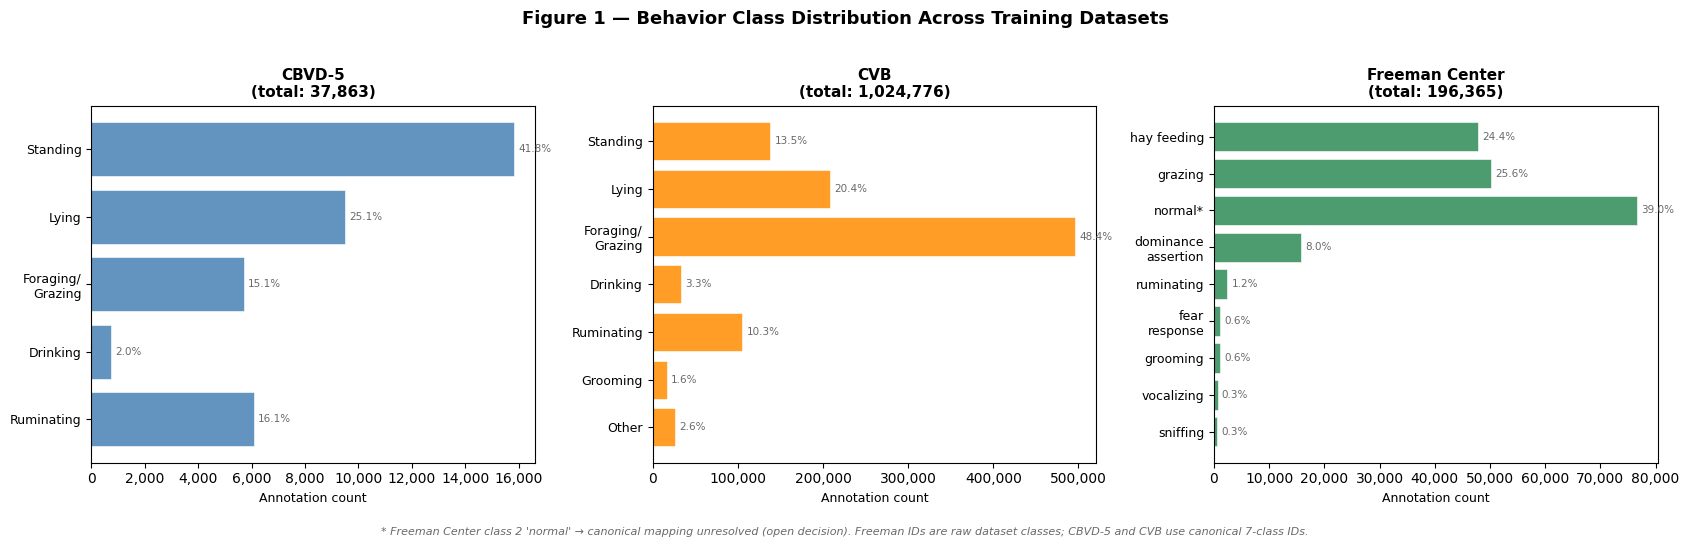

Saved: results/analysis/comparison_behavior_distribution.png


In [2]:
# Canonical 7-class label names (used for CBVD-5 and CVB)
CANONICAL_LABELS = {
    "0": "Standing",
    "1": "Lying",
    "2": "Foraging/\nGrazing",
    "3": "Drinking",
    "4": "Ruminating",
    "5": "Grooming",
    "6": "Other",
}

# Freeman raw class names (IDs 0–8)
FREEMAN_LABELS = {
    "0": "hay feeding",
    "1": "grazing",
    "2": "normal*",  # * = OPEN DECISION
    "3": "dominance\nassertion",
    "4": "ruminating",
    "5": "fear\nresponse",
    "6": "grooming",
    "7": "vocalizing",
    "8": "sniffing",
}

behavior_datasets = [
    ("cbvd5", "CBVD-5", CANONICAL_LABELS, "steelblue"),
    ("cvb", "CVB", CANONICAL_LABELS, "darkorange"),
    ("freeman", "Freeman Center", FREEMAN_LABELS, "seagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "Figure 1 — Behavior Class Distribution Across Training Datasets",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

for ax, (key, title, label_map, color) in zip(axes, behavior_datasets):
    dist = summaries[key]["class_distribution"]
    class_ids = sorted(dist.keys(), key=lambda x: int(x))
    counts = [dist[cid] for cid in class_ids]
    labels = [label_map.get(cid, cid) for cid in class_ids]
    total = sum(counts)

    bars = ax.barh(
        range(len(labels)),
        counts,
        color=color,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Annotation count", fontsize=9)
    ax.set_title(f"{title}\n(total: {total:,})", fontsize=11, fontweight="bold")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

    for bar, count in zip(bars, counts):
        pct = 100 * count / total
        ax.text(
            bar.get_width() + max(counts) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%",
            va="center",
            fontsize=7.5,
            color="dimgray",
        )

# Footnote for Freeman open decision
fig.text(
    0.5,
    -0.03,
    "* Freeman Center class 2 'normal' → canonical mapping unresolved (open decision)."
    " Freeman IDs are raw dataset classes; CBVD-5 and CVB use canonical 7-class IDs.",
    ha="center",
    fontsize=8,
    color="dimgray",
    style="italic",
)

plt.tight_layout()
out1 = RESULTS_DIR / "comparison_behavior_distribution.png"
plt.savefig(out1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out1.relative_to(REPO_ROOT)}")

---

## Figure 2 — Dataset Scale Comparison

Compares all six datasets by total image/frame count and total annotation count. Distinguishes training datasets (behavior labels) from evaluation-only datasets (detection/tracking).


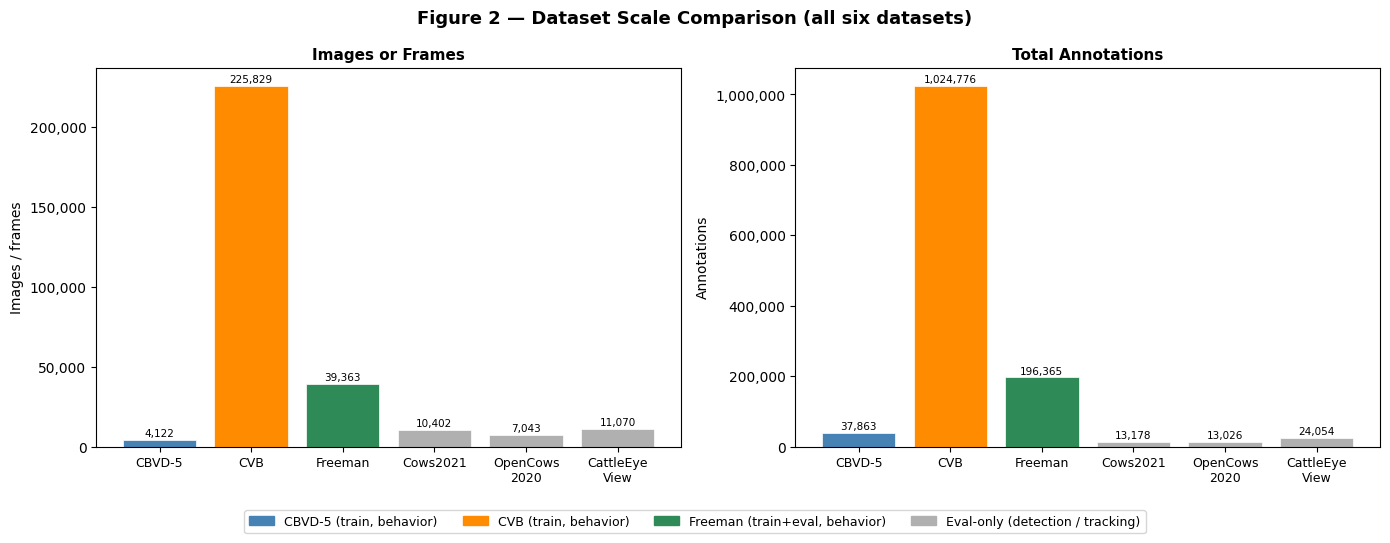

Saved: results/analysis/comparison_dataset_scale.png


In [3]:
DISPLAY_NAMES = {
    "cbvd5": "CBVD-5",
    "cvb": "CVB",
    "freeman": "Freeman",
    "cows2021": "Cows2021",
    "opencows2020": "OpenCows\n2020",
    "cattleeyeview": "CattleEye\nView",
}

# Color by role: training (behavior) vs. eval-only
ROLE_COLOR = {
    "cbvd5": "steelblue",
    "cvb": "darkorange",
    "freeman": "seagreen",
    "cows2021": "#b0b0b0",
    "opencows2020": "#b0b0b0",
    "cattleeyeview": "#b0b0b0",
}

frame_counts = [summaries[k]["total_images_or_frames"] for k in DATASET_KEYS]
annot_counts = [summaries[k]["total_annotations"] for k in DATASET_KEYS]
names = [DISPLAY_NAMES[k] for k in DATASET_KEYS]
colors = [ROLE_COLOR[k] for k in DATASET_KEYS]

x = np.arange(len(DATASET_KEYS))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Figure 2 — Dataset Scale Comparison (all six datasets)",
    fontsize=13,
    fontweight="bold",
)

for ax, counts, ylabel, title_suffix in [
    (axes[0], frame_counts, "Images / frames", "Images or Frames"),
    (axes[1], annot_counts, "Annotations", "Total Annotations"),
]:
    bars = ax.bar(x, counts, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title_suffix, fontsize=11, fontweight="bold")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            f"{count:,}",
            ha="center",
            fontsize=7.5,
            rotation=0,
        )

# Shared legend
legend_patches = [
    mpatches.Patch(color="steelblue", label="CBVD-5 (train, behavior)"),
    mpatches.Patch(color="darkorange", label="CVB (train, behavior)"),
    mpatches.Patch(color="seagreen", label="Freeman (train+eval, behavior)"),
    mpatches.Patch(color="#b0b0b0", label="Eval-only (detection / tracking)"),
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.08),
)

plt.tight_layout()
out2 = RESULTS_DIR / "comparison_dataset_scale.png"
plt.savefig(out2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out2.relative_to(REPO_ROOT)}")

---

## Figure 3 — Evaluation Scope Summary Table

One row per dataset: annotation format, native resolution, whether behavior labels are present, and the Phase 8 evaluation tasks. This table is designed for direct inclusion in the thesis methodology chapter.


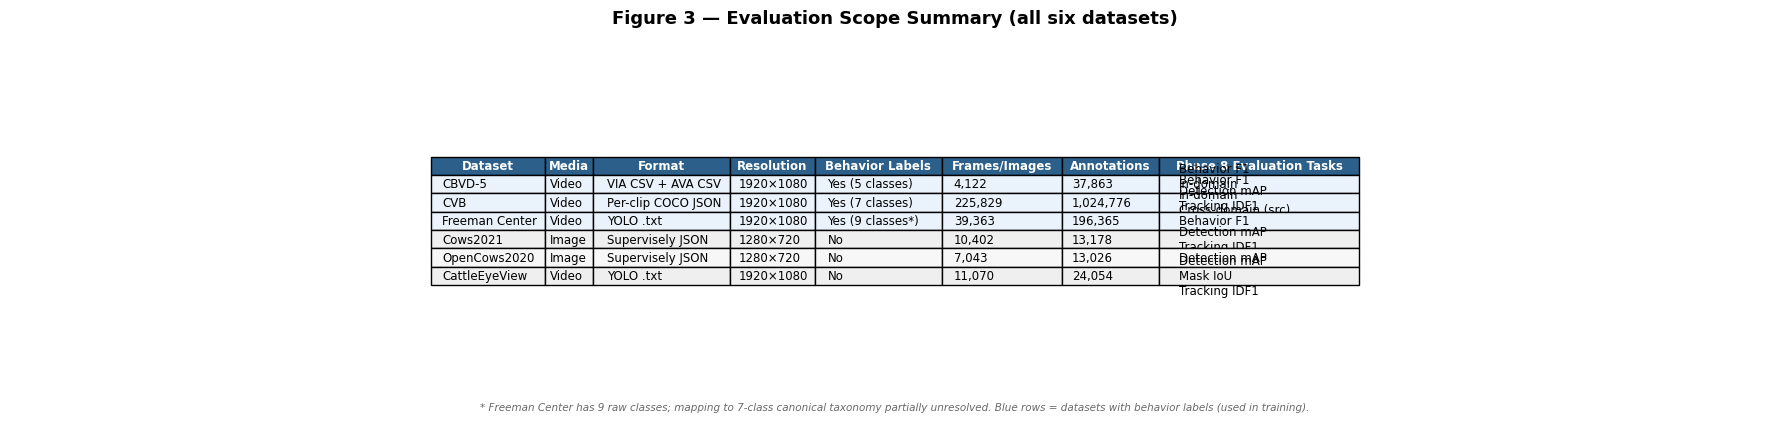

Saved: results/analysis/comparison_evaluation_scope.png


In [4]:
# Build the table rows from summary JSONs + static metadata
STATIC_META = {
    "cbvd5": {
        "full_name": "CBVD-5",
        "format": "VIA CSV + AVA CSV",
        "media": "Video",
        "behavior_labels": "Yes (5 classes)",
    },
    "cvb": {
        "full_name": "CVB",
        "format": "Per-clip COCO JSON",
        "media": "Video",
        "behavior_labels": "Yes (7 classes)",
    },
    "freeman": {
        "full_name": "Freeman Center",
        "format": "YOLO .txt",
        "media": "Video",
        "behavior_labels": "Yes (9 classes*)",
    },
    "cows2021": {
        "full_name": "Cows2021",
        "format": "Supervisely JSON",
        "media": "Image",
        "behavior_labels": "No",
    },
    "opencows2020": {
        "full_name": "OpenCows2020",
        "format": "Supervisely JSON",
        "media": "Image",
        "behavior_labels": "No",
    },
    "cattleeyeview": {
        "full_name": "CattleEyeView",
        "format": "YOLO .txt",
        "media": "Video",
        "behavior_labels": "No",
    },
}

SCOPE_LABELS = {
    "behavior_f1": "Behavior F1",
    "in_domain": "In-domain",
    "cross_domain_source": "Cross-domain (src)",
    "cross_domain_target": "Cross-domain (tgt)",
    "detection_map": "Detection mAP",
    "tracking_idf1": "Tracking IDF1",
    "mask_iou": "Mask IoU",
    "activity_budgets": "Activity budgets",
    "ood_generalization": "OOD generalization",
}

rows = []
for key in DATASET_KEYS:
    s = summaries[key]
    m = STATIC_META[key]
    res = s["resolution"]
    scope_str = "\n".join(SCOPE_LABELS.get(t, t) for t in s["evaluation_scope"])
    rows.append(
        [
            m["full_name"],
            m["media"],
            m["format"],
            f"{res['width']}×{res['height']}",
            m["behavior_labels"],
            f"{s['total_images_or_frames']:,}",
            f"{s['total_annotations']:,}",
            scope_str,
        ]
    )

col_headers = [
    "Dataset",
    "Media",
    "Format",
    "Resolution",
    "Behavior Labels",
    "Frames/Images",
    "Annotations",
    "Phase 8 Evaluation Tasks",
]

fig, ax = plt.subplots(figsize=(18, 4.2))
ax.axis("off")
ax.set_title(
    "Figure 3 — Evaluation Scope Summary (all six datasets)",
    fontsize=13,
    fontweight="bold",
    pad=14,
)

tbl = ax.table(
    cellText=rows,
    colLabels=col_headers,
    loc="center",
    cellLoc="left",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.auto_set_column_width(col=list(range(len(col_headers))))

# Style header row
for col_idx in range(len(col_headers)):
    cell = tbl[0, col_idx]
    cell.set_facecolor("#2c5f8a")
    cell.set_text_props(color="white", fontweight="bold")

# Highlight behavior datasets and alternate row shading
BEHAVIOR_KEYS = {"cbvd5", "cvb", "freeman"}
for row_idx, key in enumerate(DATASET_KEYS, start=1):
    bg = "#eaf2fb" if key in BEHAVIOR_KEYS else "#f7f7f7"
    if row_idx % 2 == 0 and key not in BEHAVIOR_KEYS:
        bg = "#efefef"
    for col_idx in range(len(col_headers)):
        tbl[row_idx, col_idx].set_facecolor(bg)

fig.text(
    0.5,
    0.01,
    "* Freeman Center has 9 raw classes; mapping to 7-class canonical taxonomy partially unresolved."
    " Blue rows = datasets with behavior labels (used in training).",
    ha="center",
    fontsize=7.5,
    color="dimgray",
    style="italic",
)

plt.tight_layout()
out3 = RESULTS_DIR / "comparison_evaluation_scope.png"
plt.savefig(out3, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out3.relative_to(REPO_ROOT)}")

---

## Cross-Dataset Summary Statistics


In [5]:
print("Cross-dataset summary")
print("=" * 72)
print()

total_frames_all = sum(summaries[k]["total_images_or_frames"] for k in DATASET_KEYS)
total_annots_all = sum(summaries[k]["total_annotations"] for k in DATASET_KEYS)
behavior_datasets_keys = [
    k for k in DATASET_KEYS if summaries[k]["has_behavior_labels"]
]
eval_only_keys = [k for k in DATASET_KEYS if not summaries[k]["has_behavior_labels"]]

print(f"Total datasets:            {len(DATASET_KEYS)}")
print(
    f"  With behavior labels:    {len(behavior_datasets_keys)}  ({', '.join(behavior_datasets_keys)})"
)
print(
    f"  Eval-only (detection):   {len(eval_only_keys)}  ({', '.join(eval_only_keys)})"
)
print()
print(f"Total images/frames:       {total_frames_all:>12,}")
print(f"Total annotations:         {total_annots_all:>12,}")
print()

print(
    f"{'Dataset':<18} {'Frames':>12} {'Annotations':>14} {'Behavior':>10} {'Role':<30}"
)
print("-" * 78)
for key in DATASET_KEYS:
    s = summaries[key]
    beh = "Yes" if s["has_behavior_labels"] else "No"
    role = ", ".join(s["evaluation_scope"][:2])
    print(
        f"{DISPLAY_NAMES[key].replace(chr(10), ' '):<18} "
        f"{s['total_images_or_frames']:>12,} "
        f"{s['total_annotations']:>14,} "
        f"{beh:>10}  "
        f"{role}"
    )
print("-" * 78)
print(f"{'TOTAL':<18} {total_frames_all:>12,} {total_annots_all:>14,}")
print()
print("Output figures:")
for out in [out1, out2, out3]:
    print(f"  {out.relative_to(REPO_ROOT)}")

Cross-dataset summary

Total datasets:            6
  With behavior labels:    3  (cbvd5, cvb, freeman)
  Eval-only (detection):   3  (cows2021, opencows2020, cattleeyeview)

Total images/frames:            297,829
Total annotations:            1,309,262

Dataset                  Frames    Annotations   Behavior Role                          
------------------------------------------------------------------------------
CBVD-5                    4,122         37,863        Yes  behavior_f1, in_domain
CVB                     225,829      1,024,776        Yes  behavior_f1, in_domain
Freeman                  39,363        196,365        Yes  detection_map, tracking_idf1
Cows2021                 10,402         13,178         No  detection_map, tracking_idf1
OpenCows 2020             7,043         13,026         No  detection_map
CattleEye View           11,070         24,054         No  detection_map, mask_iou
------------------------------------------------------------------------------
T